# Inception 网络图像分类实战（CIFAR-10 数据集）

> 本 Notebook 基于 PyTorch 从零实现简化版 InceptionNet，在 CIFAR-10 数据集上进行 10 类图像分类训练，涵盖数据准备、模型定义、训练、评估与预测的完整流程。

## 一、环境配置与依赖导入

In [20]:
import matplotlib as mpl           # matplotlib：Python 最常用的绘图库
import matplotlib.pyplot as plt    # pyplot 子模块：提供类似 MATLAB 的绘图接口
%matplotlib inline                 
# Jupyter Magic 命令：让图像直接在 notebook 中显示

import numpy as np                 # NumPy：高性能数值计算库，提供 ndarray 等数据结构
import sklearn                     # Scikit-learn：机器学习工具库（用于评估指标等）
import pandas as pd                # Pandas：表格型数据处理库，提供 DataFrame 结构
import os                          # os：操作系统接口，用于路径、目录操作
import sys                         # sys：Python 解释器相关信息
import time                        # time：时间相关工具（本文件中备用）
from tqdm import tqdm         # tqdm：进度条库，auto 模式自动适配 Jupyter / 终端

import torch                       # PyTorch 主库
import torch.nn as nn              # nn 模块：封装了各种神经网络层、损失函数等
import torch.nn.functional as F    # F 模块：以函数形式提供激活函数、填充等操作

print(sys.version_info)            # 打印 Python 解释器版本信息（major/minor/micro 等）
for module in mpl, np, pd, sklearn, torch:  # 循环遍历序列中的每个元素
    print(module.__name__, module.__version__)  # 依次打印每个库的名称和版本号，格式：库名 版本号

# ── 选择运算设备 ──────────────────────────────────────────────────────────────
# torch.cuda.is_available()：检查当前环境是否有可用的 CUDA GPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")  # ── 选择运算设备 ──────────────────────────────────────────────────────────────；torch.cuda.is_available()：检查当前环境是否有可用的 CUDA GPU；若有 GPU 则使用第 0 块 GPU（cuda:0），否则使用 CPU
print(device)   # 输出当前所用设备，例如 "cpu" 或 "cuda:0"

seed = 42       # 随机种子值，42 是社区惯例，可更改为任意整数


sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 二、数据准备

数据集来源：[CIFAR-10 Kaggle 竞赛](https://www.kaggle.com/competitions/cifar-10/data)

```shell
cifar-10
├── sampleSubmission.csv
├── test
├── train
└── trainLabels.csv
```

### 2.1 解析标签 CSV 文件

In [21]:
from pathlib import Path   # pathlib.Path：面向对象的路径操作类，比 os.path 更简洁

DATA_DIR = Path("data/cifar-10")                       # CIFAR-10 数据集根目录（Windows 路径）

train_lables_file = DATA_DIR / "trainLabels.csv"     # 训练集标签 CSV 文件路径
test_csv_file = DATA_DIR / "sampleSubmission.csv"    # 测试集提交模板 CSV 文件路径
train_folder = DATA_DIR / "train"                    # 训练图像所在文件夹
test_folder = DATA_DIR / "test"                      # 测试图像所在文件夹

class_names = [  # ── CIFAR-10 的 10 个类别名称，顺序对应标签索引 0~9 ──────────────────────────
    'airplane',    # 飞机（类别索引 0）
    'automobile',  # 汽车（类别索引 1）
    'bird',        # 鸟  （类别索引 2）
    'cat',         # 猫  （类别索引 3）
    'deer',        # 鹿  （类别索引 4）
    'dog',         # 狗  （类别索引 5）
    'frog',        # 青蛙（类别索引 6）
    'horse',       # 马  （类别索引 7）
    'ship',        # 船  （类别索引 8）
    'truck',       # 卡车（类别索引 9）
]  # 列表定义结束


def parse_csv_file(filepath, folder):  # 定义函数 parse_csv_file，实现数据处理或训练评估流程
    """解析 CSV 标签文件，返回 (图像完整路径, 类别名称) 的列表。

    参数:
        filepath (str | Path): CSV 文件路径。
            - 训练集 CSV 格式：id,label（第一行为表头）
            - 测试集 CSV 格式：id,label（label 为占位符）
        folder (str | Path): 对应图像文件夹路径。

    返回:
        list[tuple[Path, str]]: 每个元素为 (图像 Path 对象, 类别字符串)，
            例如 (WindowsPath('D:/cifar-10/train/1.png'), 'frog')。
    """
    results = []  # 变量赋值：保存中间结果或配置
    with open(filepath, 'r') as f:  # 上下文管理器：自动处理资源打开与关闭
        # readlines() 读取所有行，返回 list[str]
        lines = f.readlines()[1:]  # readlines() 读取所有行，返回 list[str]；[1:]：跳过第一行（表头 "id,label"），从第二行开始解析

    for line in lines:          # 遍历每一行数据
        image_id, label_str = line.strip('\n').split(',')  # strip('\n')：去除末尾的换行符；split(',')：按逗号分割为 [image_id, label_str]
        image_full_path = folder / f"{image_id}.png"  # 拼接完整图像路径，CIFAR-10 图像为 PNG 格式，文件名为 image_id.png
        results.append((image_full_path, label_str))  # 加入结果列表

    return results   # 返回 list[tuple]：[(图像路径, 类别字符串), ...]


train_labels_info = parse_csv_file(train_lables_file, train_folder)  # 训练集：50000 条
test_csv_info = parse_csv_file(test_csv_file, test_folder)           # 测试集：300000 条

import pprint  # ── 打印前 5 条数据预览 ───────────────────────────────────────────────────────
pprint.pprint(train_labels_info[0:5])   # 打印前 5 条训练集 (路径, 标签) 元组
pprint.pprint(test_csv_info[0:5])       # 打印前 5 条测试集 (路径, 标签) 元组
print(len(train_labels_info), len(test_csv_info))  # 输出总样本数


[(WindowsPath('data/cifar-10/train/1.png'), 'frog'),
 (WindowsPath('data/cifar-10/train/2.png'), 'truck'),
 (WindowsPath('data/cifar-10/train/3.png'), 'truck'),
 (WindowsPath('data/cifar-10/train/4.png'), 'deer'),
 (WindowsPath('data/cifar-10/train/5.png'), 'automobile')]
[(WindowsPath('data/cifar-10/test/1.png'), 'cat'),
 (WindowsPath('data/cifar-10/test/2.png'), 'cat'),
 (WindowsPath('data/cifar-10/test/3.png'), 'cat'),
 (WindowsPath('data/cifar-10/test/4.png'), 'cat'),
 (WindowsPath('data/cifar-10/test/5.png'), 'cat')]
50000 300000


### 2.2 划分训练集、验证集与测试集

In [22]:
# ── 将 list[tuple] 转为 pandas DataFrame，方便后续 Dataset 使用 ────────────────
train_df = pd.DataFrame(train_labels_info[0:45000])   # 训练集 DataFrame，形状 (45000, 2)
valid_df = pd.DataFrame(train_labels_info[45000:])    # 验证集 DataFrame，形状 (5000,  2)
test_df  = pd.DataFrame(test_csv_info)                # 测试集 DataFrame，形状 (300000, 2)

# ── 为 DataFrame 的两列命名 ───────────────────────────────────────────────────
train_df.columns = ['filepath', 'class']  # ── 为 DataFrame 的两列命名 ───────────────────────────────────────────────────；原始数据无列名，这里手动指定 'filepath'（路径）和 'class'（类别字符串）
valid_df.columns = ['filepath', 'class']  # 变量赋值：保存中间结果或配置
test_df.columns  = ['filepath', 'class']  # 变量赋值：保存中间结果或配置

print(train_df.head())   # head() 默认显示前 5 行
print(valid_df.head())  # 打印变量到控制台，便于调试与验证
print(test_df.head())  # 打印变量到控制台，便于调试与验证


                    filepath       class
0  data\cifar-10\train\1.png        frog
1  data\cifar-10\train\2.png       truck
2  data\cifar-10\train\3.png       truck
3  data\cifar-10\train\4.png        deer
4  data\cifar-10\train\5.png  automobile
                        filepath       class
0  data\cifar-10\train\45001.png       horse
1  data\cifar-10\train\45002.png  automobile
2  data\cifar-10\train\45003.png        deer
3  data\cifar-10\train\45004.png  automobile
4  data\cifar-10\train\45005.png    airplane
                   filepath class
0  data\cifar-10\test\1.png   cat
1  data\cifar-10\test\2.png   cat
2  data\cifar-10\test\3.png   cat
3  data\cifar-10\test\4.png   cat
4  data\cifar-10\test\5.png   cat


### 2.3 自定义 Dataset 与数据增强变换

In [23]:
from PIL import Image                              # PIL.Image：用于打开和处理图像文件
from torch.utils.data import Dataset, DataLoader  # Dataset：抽象数据集基类；DataLoader：批量加载器
from torchvision import transforms                 # transforms：图像预处理与数据增强工具集


class Cifar10Dataset(Dataset):  # 定义类 Cifar10Dataset，封装网络结构或回调逻辑
    """自定义 CIFAR-10 数据集类，继承自 torch.utils.data.Dataset。

    通过实现 __init__、__getitem__、__len__ 三个方法，
    使其可被 DataLoader 批量采样。

    类属性:
        df_map (dict): 模式名称 -> DataFrame 的映射，支持 'train'/'eval'/'test' 三种模式。
        label_to_idx (dict): 类别字符串 -> 整数索引，如 'cat' -> 3。
        idx_to_label (dict): 整数索引 -> 类别字符串，如 3 -> 'cat'。
    """

    df_map = {  # 类级别共享变量：三种模式对应的 DataFrame
        "train": train_df,   # 训练集 DataFrame（45000 条）
        "eval": valid_df,    # 验证集 DataFrame（5000 条）
        "test": test_df      # 测试集 DataFrame（300000 条）
    }  # 字典定义结束

    label_to_idx = {label: idx for idx, label in enumerate(class_names)}  # 类别名称 <-> 整数索引 的双向映射（由 enumerate 生成）
    idx_to_label = {idx: label for idx, label in enumerate(class_names)}  # 索引到类别名的反向映射字典，便于预测结果解码

    def __init__(self, mode, transform=None):  # 定义函数 __init__，实现数据处理或训练评估流程
        """初始化数据集。

        参数:
            mode (str): 数据集模式，必须为 'train'、'eval' 或 'test' 之一。
            transform (callable, optional): torchvision.transforms 组合变换，
                用于图像预处理（resize、normalize 等），默认 None 表示不变换。

        异常:
            ValueError: 当 mode 不在 df_map 中时抛出。
        """
        self.df = self.df_map.get(mode, None)        # 根据 mode 获取对应 DataFrame
        if self.df is None:  # 条件分支：按条件执行不同逻辑
            raise ValueError("mode should be one of train, val, test, but got {}".format(mode))  # 若 mode 不合法，抛出异常并提示正确的取值范围

        self.transform = transform   # 保存图像变换管道，__getitem__ 中使用

    def __getitem__(self, index):  # 定义函数 __getitem__，实现数据处理或训练评估流程
        """按索引返回单个样本（图像张量, 类别整数索引）。

        参数:
            index (int): 样本在 DataFrame 中的行索引，由 DataLoader 传入。

        返回:
            tuple[Tensor, int]:
                - img (Tensor): 形状为 (C, H, W) 的浮点张量，C=3（RGB），H=W=IMAGE_SIZE。
                - label (int): 类别整数索引（0~9）。
        """
        img_path, label = self.df.iloc[index]        # 按行取出图像路径和类别字符串
        img = Image.open(img_path).convert('RGB')    # 打开图像并强制转为 RGB 三通道
        img = self.transform(img)                    # 应用数据增强/预处理变换，返回 Tensor
        label = self.label_to_idx[label]             # 将类别字符串转为整数索引
        return img, label                            # 返回 (图像张量, 类别索引)

    def __len__(self):  # 定义函数 __len__，实现数据处理或训练评估流程
        """返回数据集的样本总数。

        返回:
            int: DataFrame 的行数，即样本总数。
        """
        return self.df.shape[0]   # shape[0] 取 DataFrame 的行数


IMAGE_SIZE = 32   # CIFAR-10 原始图像大小为 32×32，不放大直接使用

# ── CIFAR-10 各通道的均值与标准差（由数据集统计得出，用于归一化） ─────────────────
# mean：RGB 三个通道的像素均值（范围 0~1）
mean, std = [0.4914, 0.4822, 0.4465], [0.247, 0.243, 0.261]  # ── CIFAR-10 各通道的均值与标准差（由数据集统计得出，用于归一化） ─────────────────；mean：RGB 三个通道的像素均值（范围 0~1）；std： RGB 三个通道的像素标准差

transforms_train = transforms.Compose([  # ── 训练集变换流水线（含数据增强，防止过拟合） ──────────────────────────────────
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # Resize：将图像缩放到 (IMAGE_SIZE, IMAGE_SIZE) 大小，参数为 (height, width)
    transforms.RandomRotation(40),  # RandomRotation：随机旋转 ±40 度，增强旋转不变性
    transforms.RandomHorizontalFlip(),  # RandomHorizontalFlip：以 0.5 概率随机水平翻转，增强左右对称不变性
    transforms.ToTensor(),  # ToTensor：将 PIL Image (H, W, C, uint8 [0,255]) 转为 Tensor (C, H, W, float32 [0,1])
    transforms.Normalize(mean, std)  # Normalize：用均值和标准差对每个通道标准化，输出均值≈0、方差≈1
])  # 函数调用或表达式结束

transforms_eval = transforms.Compose([  # ── 验证/测试集变换流水线（不做数据增强，只做标准化） ────────────────────────────
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # 统一尺寸
    transforms.ToTensor(),                         # 转为 Tensor
    transforms.Normalize(mean, std)               # 标准化
])  # 函数调用或表达式结束

train_ds = Cifar10Dataset("train", transforms_train)  # 训练集，含数据增强
eval_ds  = Cifar10Dataset("eval", transforms_eval)    # 验证集，不做增强


### 2.4 构建 DataLoader（批量数据加载器）

In [24]:
# ── 批量大小设置 ──────────────────────────────────────────────────────────────
batch_size = 64  # ── 批量大小设置 ──────────────────────────────────────────────────────────────；batch_size：每次从数据集中取出的样本数量，影响训练速度和梯度估计质量

# ── 构建训练集 DataLoader ──────────────────────────────────────────────────────
# DataLoader 参数说明：
#   dataset     (Dataset): 数据集对象，需实现 __len__ 和 __getitem__
#   batch_size  (int):     每批样本数
#   shuffle     (bool):    True 表示每个 epoch 开始前随机打乱数据顺序，训练集必须开启
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)  

# ── 构建验证集 DataLoader ──────────────────────────────────────────────────────
eval_dl = DataLoader(eval_ds, batch_size=batch_size*2, shuffle=False)  # 验证集不需要打乱（shuffle=False），保证每次评估顺序一致


## 三、定义模型

### 3.1 InceptionBlock 与 InceptionNet 模型定义

In [25]:

class InceptionBlock(nn.Module):  # 定义类 InceptionBlock，封装网络结构或回调逻辑
    """Inception 模块（简化版）：并行使用多种卷积核提取不同尺度的特征，再拼接输出。

    本模块包含四条并行路径：
        - 路径 1：1×1 卷积（捕捉点级特征，降维/升维）
        - 路径 2：3×3 卷积（捕捉局部纹理特征）
        - 路径 3：5×5 卷积（捕捉较大感受野的特征）
        - 路径 4：MaxPool 2×2，步幅 2（下采样后用零填充恢复尺寸）

    所有路径均保持空间分辨率（padding='same'），最终在 channel 维度拼接。

    参数:
        input_channels (int): 输入特征图的通道数。
        output_channel_for_each_path (list[int]): 长度为 3 的列表，
            依次指定路径 1、2、3 的输出通道数（路径 4 通道数 = input_channels）。
    """

    def __init__(self, input_channels: int, output_channel_for_each_path: list[int]):  # 定义函数 __init__，实现数据处理或训练评估流程
        """初始化各路径的卷积层和批归一化层。

        参数:
            input_channels (int): 输入特征图的通道数。
            output_channel_for_each_path (list[int]): 各路径（1×1、3×3、5×5）的输出通道数列表。
        """
        super(InceptionBlock, self).__init__()   # 调用父类 nn.Module 的构造函数

        # ── 路径 1：1×1 卷积，捕捉点特征，同时可做跨通道信息融合 ────────────────
        self.conv1_1 = nn.Conv2d(input_channels, output_channel_for_each_path[0],  # padding='same' 确保输出 H, W 与输入相同
                                 kernel_size=1, padding="same")  # 函数调用或表达式结束

        # ── 路径 2：3×3 卷积，捕捉局部空间特征 ─────────────────────────────────
        self.conv3_3 = nn.Conv2d(input_channels, output_channel_for_each_path[1],  
                                 kernel_size=3, padding="same")  # 函数调用或表达式结束

        # ── 路径 3：5×5 卷积，捕捉较大感受野的空间特征 ──────────────────────────
        self.conv5_5 = nn.Conv2d(input_channels, output_channel_for_each_path[2],  
                                 kernel_size=5, padding="same")  # 函数调用或表达式结束

        # ── 路径 4：最大池化（stride=2 会将尺寸减半，forward 中用 pad 补回） ──────
        self.max_pooling = nn.MaxPool2d(kernel_size=2, stride=2)  # kernel_size=2, stride=2：无重叠的 2×2 最大池化

        # ── 批归一化层（Batch Normalization）────────────────────────────────────
        self.bn1 = nn.BatchNorm2d(output_channel_for_each_path[0])  # 对应路径 1
        self.bn2 = nn.BatchNorm2d(output_channel_for_each_path[1])  # 对应路径 2
        self.bn3 = nn.BatchNorm2d(output_channel_for_each_path[2])  # 对应路径 3

    def forward(self, x):  # 定义函数 forward，实现数据处理或训练评估流程
        """前向传播：并行计算四条路径，拼接后返回。

        参数:
            x (Tensor): 输入特征图，形状 (N, C_in, H, W)。

        返回:
            Tensor: 拼接后的特征图，形状 (N, C_out_1+C_out_2+C_out_3+C_in, H, W)，
                C_out_i 为第 i 路径的输出通道数，C_in 来自最大池化路径。
        """
        conv1_1 = F.relu(self.bn1(self.conv1_1(x)))   # 1×1 卷积路径输出
        conv3_3 = F.relu(self.bn2(self.conv3_3(x)))   # 3×3 卷积路径输出
        conv5_5 = F.relu(self.bn3(self.conv5_5(x)))   # 5×5 卷积路径输出

        max_pooling = self.max_pooling(x)   # 输出形状 (N, C_in, H//2, W//2)

        input_shape = x.shape[2:]                      # 取输入的 (H, W)
        max_pooling_shape = max_pooling.shape[2:]      # 取池化后的 (H//2, W//2)
        height_padding = (input_shape[0] - max_pooling_shape[0]) // 2  # 计算高度和宽度方向各需要填充多少像素（两侧均分）
        width_padding  = (input_shape[1] - max_pooling_shape[1]) // 2  # 变量赋值：保存中间结果或配置
        padded_pooling = F.pad(  # F.pad 参数：[左, 右, 上, 下]，对最后两维（W, H）进行零填充
            max_pooling,  # 容器/参数列表中的下一项
            [width_padding, width_padding, height_padding, height_padding]  # 执行当前语句，推进数据处理或训练流程
        )   # 填充后形状恢复为 (N, C_in, H, W)

        # ── 沿 channel 维度（dim=1）拼接所有路径的输出 ──────────────────────────
        concat_output = torch.cat([conv1_1, conv3_3, conv5_5, padded_pooling], dim=1)  # ── 沿 channel 维度（dim=1）拼接所有路径的输出 ──────────────────────────；拼接后通道数 = out_ch1 + out_ch2 + out_ch3 + input_channels
        return concat_output  # 返回计算结果给调用方


class InceptionNet(nn.Module):  # 定义类 InceptionNet，封装网络结构或回调逻辑
    """基于 InceptionBlock 搭建的图像分类网络，用于 CIFAR-10（10 类）。

    网络结构（顺序）：
        1. 初始 3×3 卷积 + BN + ReLU
        2. InceptionBlock（32通道 × 3路 + 32池化 = 128通道输出）
        3. InceptionBlock（128→64×3 + 128池化 = 320通道输出）
        4. MaxPool 2×2（空间尺寸减半）
        5. InceptionBlock（320→128×3 + 320池化 = 704通道输出）
        6. InceptionBlock（704→256×3 + 704池化 = 1472通道输出）
        7. Global Average Pooling（自适应平均池化到 1×1）
        8. Flatten（展平为一维向量）
        9. Dropout(0.5)（随机丢弃 50% 神经元，防止过拟合）
        10. 全连接层（1472 -> num_classes）

    参数:
        num_classes (int): 分类类别数，默认 10（CIFAR-10）。
    """

    def __init__(self, num_classes=10):  # 定义函数 __init__，实现数据处理或训练评估流程
        """初始化网络各层。

        参数:
            num_classes (int): 分类类别数，默认为 10。
        """
        super(InceptionNet, self).__init__()   # 调用父类构造函数

        self.model = nn.Sequential(  # ── 使用 nn.Sequential 顺序定义整个网络 ──────────────────────────────────
            # 第 0 层：初始特征提取卷积，将 3 通道 RGB 映射到 32 通道特征图
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding="same"),  # 第 0 层：初始特征提取卷积，将 3 通道 RGB 映射到 32 通道特征图；kernel_size=3, stride=1, padding='same'：保持空间尺寸不变
            nn.BatchNorm2d(32),   # 对 32 通道做批归一化
            nn.ReLU(),            # ReLU 激活函数，引入非线性

            # 第 3 层：第 1 个 InceptionBlock，输入 32 通道
            # output_channel_for_each_path=[32,32,32]：三条卷积路径各输出 32 通道
            InceptionBlock(32, [32, 32, 32]),  # 第 3 层：第 1 个 InceptionBlock，输入 32 通道；output_channel_for_each_path=[32,32,32]：三条卷积路径各输出 32 通道；最大池化路径保留 32 通道，拼接后共 32×3 + 32 = 128 通道

            # 第 4 层：第 2 个 InceptionBlock，输入 128 通道
            # 三条卷积路径各输出 64 通道，池化路径保留 128 通道
            InceptionBlock(128, [64, 64, 64]),  # 第 4 层：第 2 个 InceptionBlock，输入 128 通道；三条卷积路径各输出 64 通道，池化路径保留 128 通道；拼接后共 64×3 + 128 = 320 通道

            nn.MaxPool2d(kernel_size=2, stride=2),  # 第 5 层：最大池化，将空间尺寸从 32×32 缩减到 16×16

            # 第 6 层：第 3 个 InceptionBlock，输入 320 通道
            # 三条卷积路径各输出 128 通道，池化路径保留 320 通道
            InceptionBlock(320, [128, 128, 128]),  # 第 6 层：第 3 个 InceptionBlock，输入 320 通道；三条卷积路径各输出 128 通道，池化路径保留 320 通道；拼接后共 128×3 + 320 = 704 通道

            # 第 7 层：第 4 个 InceptionBlock，输入 704 通道
            # 三条卷积路径各输出 256 通道，池化路径保留 704 通道
            InceptionBlock(704, [256, 256, 256]),  # 第 7 层：第 4 个 InceptionBlock，输入 704 通道；三条卷积路径各输出 256 通道，池化路径保留 704 通道；拼接后共 256×3 + 704 = 1472 通道

            # 第 8 层：全局平均池化，将特征图从 (N, 1472, H, W) 压缩到 (N, 1472, 1, 1)
            nn.AdaptiveAvgPool2d((1, 1)),  # 第 8 层：全局平均池化，将特征图从 (N, 1472, H, W) 压缩到 (N, 1472, 1, 1)；AdaptiveAvgPool2d((1, 1))：自适应输出大小为 1×1，无论输入 H、W 为多少均可

            nn.Flatten(),  # 第 9 层：展平，将 (N, 1472, 1, 1) → (N, 1472)，为全连接层做准备

            nn.Dropout(0.5),  # 第 10 层：Dropout，训练时随机将 50% 的神经元置零，减少过拟合

            nn.Linear(1472, num_classes)  # 第 11 层：全连接分类头，将 1472 维特征映射到 num_classes（10）维 logits
        )  # 闭合上一行的函数调用或容器定义
        self.init_weights()   # 使用 Xavier 均匀初始化参数

    def init_weights(self):  # 定义函数 init_weights，实现数据处理或训练评估流程
        """使用 Xavier 均匀初始化所有线性层和卷积层的权重，偏置初始化为 0。

        Xavier 初始化可以保证前向传播时各层输出的方差相近，
        有助于深层网络训练时避免梯度消失/爆炸。
        """
        for m in self.modules():   # 遍历模型中的所有子模块
            if isinstance(m, (nn.Linear, nn.Conv2d)):  # 条件分支：按条件执行不同逻辑
                nn.init.xavier_uniform_(m.weight)  # xavier_uniform_：原地用 Xavier 均匀分布初始化权重矩阵
                nn.init.zeros_(m.bias)  # zeros_：将偏置初始化为全 0

    def forward(self, x):  # 定义函数 forward，实现数据处理或训练评估流程
        """前向传播：依次通过 nn.Sequential 定义的各层。

        参数:
            x (Tensor): 输入图像批次，形状 (N, 3, H, W)，
                N 为批量大小，H=W=IMAGE_SIZE=32。

        返回:
            Tensor: 分类 logits，形状 (N, num_classes)，未经过 softmax。
        """
        return self.model(x)   # 通过 Sequential 依次执行各层


# ── 打印模型所有可学习参数及其参数量 ───────────────────────────────────────────
# named_parameters()：返回 (参数名, 参数张量) 的迭代器
for key, value in InceptionNet(len(class_names)).named_parameters():  # ── 打印模型所有可学习参数及其参数量 ───────────────────────────────────────────；named_parameters()：返回 (参数名, 参数张量) 的迭代器；np.prod(value.shape)：将参数的各维度相乘，得到该参数的元素总数
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")  # 打印变量到控制台，便于调试与验证


             model.0.weight             paramerters num: 864
              model.0.bias              paramerters num: 32
             model.1.weight             paramerters num: 32
              model.1.bias              paramerters num: 32
         model.3.conv1_1.weight         paramerters num: 1024
          model.3.conv1_1.bias          paramerters num: 32
         model.3.conv3_3.weight         paramerters num: 9216
          model.3.conv3_3.bias          paramerters num: 32
         model.3.conv5_5.weight         paramerters num: 25600
          model.3.conv5_5.bias          paramerters num: 32
           model.3.bn1.weight           paramerters num: 32
            model.3.bn1.bias            paramerters num: 32
           model.3.bn2.weight           paramerters num: 32
            model.3.bn2.bias            paramerters num: 32
           model.3.bn3.weight           paramerters num: 32
            model.3.bn3.bias            paramerters num: 32
         model.4.conv1_1.weight 

### 3.2 验证输出通道数计算（第 4 个 InceptionBlock）

In [26]:
# ── 手动验算第 4 个 InceptionBlock 的输出通道数 ─────────────────────────────────
# 第 4 个 InceptionBlock 输入通道数 = 704，各卷积路径输出 256 通道
# 输出通道数 = 256（路径1）+ 256（路径2）+ 256（路径3）+ 704（池化路径保留输入通道）
704 + 256 * 3  # ── 手动验算第 4 个 InceptionBlock 的输出通道数 ─────────────────────────────────；第 4 个 InceptionBlock 输入通道数 = 704，各卷积路径输出 256 通道；输出通道数 = 256（路径1）+ 256（路径2）+ 256（路径3）+ 704（池化路径保留输入通道）；即 1×256×3 + 704 = 1472，也就是送入 Linear 层的特征维度


1472

### 3.3 模型前向推理验证（输出形状检查）

In [27]:
# ── 构造随机输入，验证模型前向推理输出形状是否正确 ────────────────────────────────
# torch.randn(N, C, H, W)：生成服从标准正态分布的随机张量
x = torch.randn(1, 3, 32, 32)  # ── 构造随机输入，验证模型前向推理输出形状是否正确 ────────────────────────────────；torch.randn(N, C, H, W)：生成服从标准正态分布的随机张量；形状 (1, 3, 32, 32)：批量大小=1，通道数=3（RGB），高=宽=32（CIFAR-10 尺寸）

model = InceptionNet(num_classes=len(class_names))  # 实例化 InceptionNet，类别数 = 10（CIFAR-10）

model(x).shape  # 执行前向传播，输出形状应为 (1, 10)，即 1 张图片的 10 类 logits


torch.Size([1, 10])

### 3.4 统计 InceptionNet 总参数量

In [28]:
# ── 统计 InceptionNet 的全部可训练参数数量 ─────────────────────────────────────
# p.numel()：返回张量 p 中的元素总数（即该参数的参数量）
total_params = sum(p.numel() for p in InceptionNet(len(class_names)).parameters()  # ── 统计 InceptionNet 的全部可训练参数数量 ─────────────────────────────────────；p.numel()：返回张量 p 中的元素总数（即该参数的参数量）；p.requires_grad：True 表示该参数参与梯度计算（即可训练参数）
                   if p.requires_grad)  # 条件分支：按条件执行不同逻辑
print(f"Total params: {total_params:,}")  # 使用 {:,} 格式化输出，每千位加一个逗号，方便阅读大数字


Total params: 8,084,010


### 3.5 对比参考：torchvision 官方 Inception V3 结构

In [29]:
# ── 对比：加载 torchvision 官方 Inception V3 模型结构 ─────────────────────────
# inception_v3()：实例化 Inception V3 模型（不加载预训练权重）
from torchvision.models import inception_v3  # ── 对比：加载 torchvision 官方 Inception V3 模型结构 ─────────────────────────；inception_v3()：实例化 Inception V3 模型（不加载预训练权重）；该模型由 Google 在 2015 年提出，专为 ImageNet 1000 类分类设计
# init_weights参数用于控制是否对模型权重进行初始化。设为True时，模型会自动调用其内部的权重初始化方法；设为False时则不会初始化权重，适用于需要手动赋值权重或加载特殊预训练权重的场景。
model = inception_v3(init_weights=True)   # 显式设置init_weights参数
model                    # 打印模型结构，可以看到 Mixed_5b~Mixed_7c 等 Inception 模块


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (con

### 3.6 Inception V3 总参数量统计

In [30]:
# ── 统计官方 Inception V3 的总参数量，与自定义 InceptionNet 对比 ────────────────
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)  # ── 统计官方 Inception V3 的总参数量，与自定义 InceptionNet 对比 ────────────────；官方 Inception V3 约有 2700 万参数，远多于本实验的 InceptionNet（约 800 万）
print(f"Total params: {total_params:,}")  # 打印变量到控制台，便于调试与验证


Total params: 27,161,264


### 3.7 辅助计算：特征图维度验算

In [31]:
# ── 辅助计算：探索某特征图空间维度的面积 ─────────────────────────────────────────
# 例如：当输入为 224×224 时，经过多层下采样后特征图可能为 4×4
224 * 4 * 4  # ── 辅助计算：探索某特征图空间维度的面积 ─────────────────────────────────────────；例如：当输入为 224×224 时，经过多层下采样后特征图可能为 4×4；此处计算 224×4×4 用于理解特征图的展平后大小（仅供学习参考）


3584

### 3.8 F.pad 零填充演示（用于 InceptionBlock 中恢复空间尺寸）

In [32]:
# ── 演示 F.pad 的用法：在特征图四周补零以恢复空间尺寸 ─────────────────────────────
# 模拟场景：输入图像 8×8，经过 stride=2 的 MaxPool 后变为 4×4
# 为了与其他路径（仍为 8×8）拼接，需要用零填充将 4×4 补回 8×8

input_shape = (3, 8, 8)        # 假设输入特征图形状：通道=3，高=8，宽=8
max_pooling_shape = (4, 4)     # MaxPool stride=2 后的空间尺寸：4×4

width_padding  = (8 - 4) // 2   # 宽度方向：(8-4)//2 = 2（左右各补 2 像素）
height_padding = (8 - 4) // 2   # 高度方向：(8-4)//2 = 2（上下各补 2 像素）

# F.pad：对张量进行填充
# 参数 1：待填充的张量，形状 (N, C, H, W) = (1, 1, 4, 4)
# 参数 2：填充序列 [左, 右, 上, 下]，指定各方向填充的像素数
#         默认填充值为 0（零填充）
padded_pooling = F.pad(  # F.pad：对张量进行填充；参数 1：待填充的张量，形状 (N, C, H, W) = (1, 1, 4, 4)；参数 2：填充序列 [左, 右, 上, 下]，指定各方向填充的像素数；默认填充值为 0（零填充）；返回值：填充后的张量，形状 (1, 1, 8, 8)
    torch.randn(1, 1, 4, 4),  # PyTorch 张量或模型相关操作
    [width_padding, width_padding, height_padding, height_padding]  # 执行当前语句，推进数据处理或训练流程
)  # 闭合上一行的函数调用或容器定义
padded_pooling   # 中间 4×4 区域为随机值，四周一圈为 0


tensor([[[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
            0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
            0.0000],
          [ 0.0000,  0.0000,  0.2057,  0.5932,  0.7399, -0.2174,  0.0000,
            0.0000],
          [ 0.0000,  0.0000,  0.5862,  0.8745, -1.1543, -0.1077,  0.0000,
            0.0000],
          [ 0.0000,  0.0000,  0.2792, -1.5743,  1.8739, -0.9771,  0.0000,
            0.0000],
          [ 0.0000,  0.0000,  0.9928,  0.7625,  0.8151, -1.0394,  0.0000,
            0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
            0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
            0.0000]]]])

## 四、定义损失函数与优化器

### 4.1 导入 torch.optim 优化器模块

In [33]:
# ── 导入 PyTorch 优化器模块 ────────────────────────────────────────────────────
# torch.optim 提供了多种梯度下降优化算法，如 SGD、Adam、RMSprop 等
import torch.optim as optim  # ── 导入 PyTorch 优化器模块 ────────────────────────────────────────────────────；torch.optim 提供了多种梯度下降优化算法，如 SGD、Adam、RMSprop 等；后续训练中将使用 torch.optim.RMSprop 作为优化器


## 五、模型训练

PyTorch 需要手动实现训练循环，主要包含以下步骤：
1. 定义损失函数
2. 定义优化器
3. 定义训练步（梯度清零 → 前向传播 → 计算损失 → 反向传播 → 参数更新）
4. 迭代训练

### 5.1 验证集评估函数

In [34]:
from sklearn.metrics import accuracy_score   # accuracy_score：计算分类准确率的函数


@torch.no_grad()  # 装饰器：修改下方函数/方法的行为
def evaluating(model, dataloader, loss_fct):  # 定义函数 evaluating，实现数据处理或训练评估流程
    """在验证集或测试集上评估模型性能，返回平均损失和准确率。

    使用 @torch.no_grad() 装饰器禁用梯度计算，节省显存并加速推理。

    参数:
        model (nn.Module): 已训练（或加载权重）的 PyTorch 模型。
        dataloader (DataLoader): 验证集或测试集的 DataLoader，
            每次迭代返回 (datas, labels) 元组。
        loss_fct (callable): 损失函数，接受 (logits, labels) 并返回标量损失。

    返回:
        tuple[float, float]:
            - 平均损失 (float)：所有 batch 损失的算术平均值。
            - 准确率 (float)：预测正确的样本比例，范围 [0, 1]。
    """
    loss_list  = []   # 存储每个 batch 的损失值
    pred_list  = []   # 存储所有 batch 的预测类别索引
    label_list = []   # 存储所有 batch 的真实类别索引
    model.eval()  # 切换为评估模式（影响 Dropout/BN）
    for datas, labels in dataloader:          # 遍历验证集所有 batch
        datas  = datas.to(device)             # 将图像数据移到指定设备（GPU 或 CPU）
        labels = labels.to(device)            # 将标签移到指定设备

        logits = model(datas)  # ── 前向计算：输入 (N, 3, H, W)，输出 logits (N, num_classes) ───────────
        loss = loss_fct(logits, labels)       # 计算当前 batch 的损失值（标量 Tensor）
        loss_list.append(loss.item())         # .item()：将标量 Tensor 转为 Python float

        # ── 取概率最大的类别索引作为预测结果 ──────────────────────────────────────
        preds = logits.argmax(axis=-1)  # ── 取概率最大的类别索引作为预测结果 ──────────────────────────────────────；logits.argmax(axis=-1)：沿最后一维（类别维度）取最大值索引，形状 (N,)
        pred_list.extend(preds.cpu().numpy().tolist())    # 移到 CPU 并转为 Python list
        label_list.extend(labels.cpu().numpy().tolist())  # 同上

    # ── 计算准确率 ──────────────────────────────────────────────────────────────
    acc = accuracy_score(label_list, pred_list)  # ── 计算准确率 ──────────────────────────────────────────────────────────────；accuracy_score(y_true, y_pred)：计算 y_true 与 y_pred 相等的比例

    return np.mean(loss_list), acc   # 返回 (平均损失, 准确率)


### 5.2 TensorBoard 可视化回调

训练过程中可以使用如下命令启动 TensorBoard 服务：

```shell
tensorboard \
    --logdir=runs \     # log 存放路径
    --host 0.0.0.0 \    # ip
    --port 8848         # 端口
```

In [35]:
from torch.utils.tensorboard import SummaryWriter   # SummaryWriter：向 TensorBoard 写入日志的工具类


class TensorBoardCallback:  # 定义类 TensorBoardCallback，封装网络结构或回调逻辑
    """TensorBoard 日志回调类，在训练循环中记录损失、准确率、学习率等指标。

    使用示例：
        callback = TensorBoardCallback(log_dir='runs/exp1')
        callback(step=100, loss=0.5, val_loss=0.6, acc=0.8, val_acc=0.75, lr=0.001)

    参数:
        log_dir (str): TensorBoard 日志文件存放目录。
        flush_secs (int): 每隔多少秒将缓冲区数据写入磁盘，默认 10 秒。
    """

    def __init__(self, log_dir, flush_secs=10):  # 定义函数 __init__，实现数据处理或训练评估流程
        """初始化 SummaryWriter。

        参数:
            log_dir (str): 日志存放路径，例如 'runs/inception_net'。
            flush_secs (int, optional): 写盘间隔秒数，默认 10 秒。
        """
        # SummaryWriter：TensorBoard 的核心写入对象
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)  # SummaryWriter：TensorBoard 的核心写入对象；log_dir：指定日志目录；flush_secs：定期刷新到磁盘

    def draw_model(self, model, input_shape):  # 定义函数 draw_model，实现数据处理或训练评估流程
        """将模型计算图写入 TensorBoard，方便可视化网络结构。

        参数:
            model (nn.Module): 要可视化的 PyTorch 模型。
            input_shape (list[int]): 示例输入的形状，如 [1, 3, 32, 32]。
        """
        # add_graph：将模型结构写入 TensorBoard
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))  # add_graph：将模型结构写入 TensorBoard；input_to_model：模拟一次前向传播所需的输入张量

    def add_loss_scalars(self, step, loss, val_loss):  # 定义函数 add_loss_scalars，实现数据处理或训练评估流程
        """在 TensorBoard 中同时绘制训练损失和验证损失曲线。

        参数:
            step (int): 当前全局训练步数（横坐标）。
            loss (float): 当前训练损失。
            val_loss (float): 当前验证损失。
        """
        # add_scalars：在同一图表中绘制多条标量曲线
        self.writer.add_scalars(  # add_scalars：在同一图表中绘制多条标量曲线；main_tag：图表标题；tag_scalar_dict：{'曲线名': 值} 字典；global_step：横坐标
            main_tag="training/loss",  # 容器/参数列表中的下一项
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},  # 容器/参数列表中的下一项
            global_step=step,  # 容器/参数列表中的下一项
        )  # 闭合上一行的函数调用或容器定义

    def add_acc_scalars(self, step, acc, val_acc):  # 定义函数 add_acc_scalars，实现数据处理或训练评估流程
        """在 TensorBoard 中同时绘制训练准确率和验证准确率曲线。

        参数:
            step (int): 当前全局训练步数（横坐标）。
            acc (float): 当前训练准确率（范围 [0, 1]）。
            val_acc (float): 当前验证准确率（范围 [0, 1]）。
        """
        self.writer.add_scalars(  # 执行当前语句，推进数据处理或训练流程
            main_tag="training/accuracy",  # 容器/参数列表中的下一项
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},  # 容器/参数列表中的下一项
            global_step=step,  # 容器/参数列表中的下一项
        )  # 闭合上一行的函数调用或容器定义

    def add_lr_scalars(self, step, learning_rate):  # 定义函数 add_lr_scalars，实现数据处理或训练评估流程
        """在 TensorBoard 中绘制学习率变化曲线。

        参数:
            step (int): 当前全局训练步数（横坐标）。
            learning_rate (float): 当前学习率值。
        """
        self.writer.add_scalars(  # 执行当前语句，推进数据处理或训练流程
            main_tag="training/learning_rate",  # 容器/参数列表中的下一项
            tag_scalar_dict={"learning_rate": learning_rate},  # 容器/参数列表中的下一项
            global_step=step,  # 容器/参数列表中的下一项
        )  # 闭合上一行的函数调用或容器定义

    def __call__(self, step, **kwargs):  # 定义函数 __call__，实现数据处理或训练评估流程
        """统一入口：根据传入的关键字参数，自动调用对应的记录方法。

        参数:
            step (int): 当前全局训练步数。
            **kwargs: 支持的关键字参数：
                - loss (float): 训练损失
                - val_loss (float): 验证损失
                - acc (float): 训练准确率
                - val_acc (float): 验证准确率
                - lr (float): 当前学习率
        """
        loss     = kwargs.pop("loss", None)      # 从 kwargs 中取出 loss，不存在则为 None
        val_loss = kwargs.pop("val_loss", None)  # 取出 val_loss
        if loss is not None and val_loss is not None:  # 条件分支：按条件执行不同逻辑
            self.add_loss_scalars(step, loss, val_loss)   # 同时传入才记录

        acc     = kwargs.pop("acc", None)        # 取出训练准确率
        val_acc = kwargs.pop("val_acc", None)    # 取出验证准确率
        if acc is not None and val_acc is not None:  # 条件分支：按条件执行不同逻辑
            self.add_acc_scalars(step, acc, val_acc)  # 函数调用或表达式结束

        learning_rate = kwargs.pop("lr", None)   # 取出学习率
        if learning_rate is not None:  # 条件分支：按条件执行不同逻辑
            self.add_lr_scalars(step, learning_rate)  # 函数调用或表达式结束


### 5.3 模型检查点保存回调

In [36]:
class SaveCheckpointsCallback:  # 定义类 SaveCheckpointsCallback，封装网络结构或回调逻辑
    """模型检查点保存回调类。

    支持两种保存策略：
        - save_best_only=True：仅保存验证指标最优的模型（推荐）。
        - save_best_only=False：每隔 save_step 步保存一次，文件名为 {step}.ckpt。

    参数:
        save_dir (str): 检查点文件存放目录。
        save_best_only (bool): 是否只保存最优模型，默认 True。
    """

    def __init__(self, save_dir, save_best_only=True):  # 定义函数 __init__，实现数据处理或训练评估流程
        """初始化检查点保存器。

        参数:
            save_dir (str): 保存目录路径，若不存在则自动创建。
            save_best_only (bool, optional): 为 True 时仅保存最优模型，默认 True。
        """
        self.save_best_only = save_best_only  # 是否只保存最优模型
        self.best_metrics  = -1            # 记录历史最优指标，初始化为 -1（无穷小）
        self.save_dir = save_dir
        if not os.path.exists(self.save_dir):  # ── 若保存目录不存在则自动创建 ────────────────────────────────────────────
            os.makedirs(self.save_dir)   # os.mkdir：创建单层目录（父目录必须已存在）

    def __call__(self, step, state_dict, metric=None):  # 定义函数 __call__，实现数据处理或训练评估流程
        """在训练循环中每步调用，决定是否保存检查点。

        参数:
            step (int): 当前全局训练步数。
            state_dict (dict): 模型参数字典，由 model.state_dict() 获取。
            metric (float, optional): 用于判断"最优"的指标值（如验证准确率），
                save_best_only=True 时必须传入。
        """

        if self.save_best_only:  # 条件分支：按条件执行不同逻辑
            assert metric is not None, "save_best_only=True 时必须提供 metric 参数"  # 断言：条件不满足时抛出异常
            if metric >= self.best_metrics:  # 条件分支：按条件执行不同逻辑
                # 当前指标优于历史最优，保存为 best.ckpt
                torch.save(state_dict, os.path.join(self.save_dir, "7_model_best.ckpt"))  # 当前指标优于历史最优，保存为 best.ckpt；torch.save：将 Python 对象序列化保存为文件（底层使用 pickle）
                self.best_metrics = metric   # 更新历史最优指标
        else:  # 否则分支：上述条件均不满足时执行
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))  # 不限制只保存最优，每隔 save_step 步均保存


### 5.4 早停回调（Early Stopping）

In [37]:
class EarlyStopCallback:  # 定义类 EarlyStopCallback，封装网络结构或回调逻辑
    """早停回调类：当验证指标在连续 patience 次评估中未显著提升时，停止训练。

    早停（Early Stopping）用于防止过拟合：
    若验证集指标长期不提升，继续训练只会浪费时间并可能导致测试集性能下降。

    参数:
        patience (int): 最大允许连续无提升的评估次数，默认 5。
        min_delta (float): 最小提升量，绝对变化小于此值视为未提升，默认 0.01。
    """

    def __init__(self, patience=5, min_delta=0.01):  # 定义函数 __init__，实现数据处理或训练评估流程
        """初始化早停器。

        参数:
            patience (int, optional): 最大容忍无提升的次数，默认 5。
            min_delta (float, optional): 最小改善阈值，默认 0.01（即 1% 的准确率提升）。
        """
        self.patience    = patience      # 最大无提升容忍次数
        self.min_delta   = min_delta     # 最小改善阈值
        self.best_metric = -1            # 记录历史最优指标值，初始化为 -1
        self.counter     = 0             # 连续无提升的计数器

    def __call__(self, metric):  # 定义函数 __call__，实现数据处理或训练评估流程
        """每次评估后调用，更新计数器。

        参数:
            metric (float): 当前评估的指标值（如验证准确率，越大越好）。
        """
        if metric >= self.best_metric + self.min_delta:  # 条件分支：按条件执行不同逻辑
            self.best_metric = metric   # 更新历史最优
            self.counter     = 0        # 重置无提升计数器
        else:  # 否则分支：上述条件均不满足时执行
            self.counter += 1  # 未见显著提升，计数器 +1

    @property  # 装饰器：修改下方函数/方法的行为
    def early_stop(self):  # 定义函数 early_stop，实现数据处理或训练评估流程
        """检查是否应该停止训练。

        返回:
            bool: 若无提升次数 >= patience，则返回 True，表示应停止训练。
        """
        return self.counter >= self.patience   # 满足条件时触发早停


### 5.5 训练主循环与超参数配置

In [38]:
%%time

def training(  # ── 定义完整训练函数 ──────────────────────────────────────────────────────────
    model,  # 容器/参数列表中的下一项
    train_loader,  # 容器/参数列表中的下一项
    val_loader,  # 容器/参数列表中的下一项
    epoch,  # 容器/参数列表中的下一项
    loss_fct,  # 容器/参数列表中的下一项
    optimizer,  # 容器/参数列表中的下一项
    tensorboard_callback=None,   # TensorBoard 回调，可选
    save_ckpt_callback=None,     # 检查点保存回调，可选
    early_stop_callback=None,    # 早停回调，可选
    eval_step=500,               # 每隔多少步在验证集上评估一次
):  # 代码块起始：下方缩进语句归属此结构
    """执行完整的训练流程，包含训练、验证、日志记录、保存和早停。

    参数:
        model (nn.Module): 待训练的 PyTorch 模型。
        train_loader (DataLoader): 训练集数据加载器。
        val_loader (DataLoader): 验证集数据加载器。
        epoch (int): 训练的总轮数（epoch 数）。
        loss_fct (callable): 损失函数，接受 (logits, labels) 返回标量损失。
        optimizer (torch.optim.Optimizer): 优化器实例。
        tensorboard_callback (TensorBoardCallback, optional): TensorBoard 日志回调。
        save_ckpt_callback (SaveCheckpointsCallback, optional): 检查点保存回调。
        early_stop_callback (EarlyStopCallback, optional): 早停回调。
        eval_step (int): 每隔多少步做一次验证集评估，默认 500。

    返回:
        dict: 训练记录字典，包含：
            - 'train': list[dict]，每步的 {'loss', 'acc', 'step'}
            - 'val':   list[dict]，每次评估的 {'loss', 'acc', 'step'}
    """
    record_dict = {  # ── 初始化记录字典 ────────────────────────────────────────────────────────────
        "train": [],   # 存储训练集每步的 loss/acc/step
        "val":   []    # 存储验证集每次评估的 loss/acc/step
    }  # 字典定义结束

    global_step = 0        # 全局训练步数计数器（跨 epoch 累计）
    model.train()          # 切换模型为训练模式（启用 Dropout、BatchNorm 的训练行为）

    # ── 外层循环：epoch ───────────────────────────────────────────────────────────
    with tqdm(total=epoch * len(train_loader)) as pbar:  # ── 外层循环：epoch ───────────────────────────────────────────────────────────；tqdm 进度条：total = 总步数 = epoch × 每 epoch 的 batch 数
        for epoch_id in range(epoch):     # 遍历每个 epoch

            for datas, labels in train_loader:  # ── 内层循环：batch ───────────────────────────────────────────────────
                datas  = datas.to(device)    # 将图像批次移到 GPU/CPU
                labels = labels.to(device)   # 将标签批次移到 GPU/CPU

                optimizer.zero_grad()  # ── 梯度清零（必须在每步反向传播前执行，否则梯度会累积） ────────────

                logits = model(datas)  # ── 模型前向计算，得到 logits（未归一化的类别分数） ─────────────────

                loss = loss_fct(logits, labels)  # ── 计算损失（交叉熵损失，内部已包含 Softmax） ───────────────────────

                loss.backward()  # ── 反向传播：计算所有参数相对于损失的梯度 ──────────────────────────

                optimizer.step()  # ── 优化器步进：根据梯度更新模型参数（含学习率调度等） ───────────────

                preds = logits.argmax(axis=-1)   # 形状 (N,)，值为 0~9

                acc  = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())  # ── 计算当前 batch 的训练准确率 ──────────────────────────────────────
                loss = loss.cpu().item()         # 将损失 Tensor 转为 Python float

                record_dict["train"].append({  # ── 记录当前步的训练指标 ─────────────────────────────────────────────
                    "loss": loss, "acc": acc, "step": global_step  # 执行当前语句，推进数据处理或训练流程
                })  # 函数调用或表达式结束

                if global_step % eval_step == 0:  # ── 每隔 eval_step 步，在验证集上评估模型 ───────────────────────────
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)  # 函数调用或表达式结束
                    record_dict["val"].append({  # 执行当前语句，推进数据处理或训练流程
                        "loss": val_loss, "acc": val_acc, "step": global_step  # 执行当前语句，推进数据处理或训练流程
                    })  # 函数调用或表达式结束
                    model.train()  # 评估结束后切回训练模式

                    if tensorboard_callback is not None:  # ── 1. TensorBoard 可视化：记录损失/准确率/学习率 ─────────────────
                        tensorboard_callback(  # 执行当前语句，推进数据处理或训练流程
                            global_step,  # 容器/参数列表中的下一项
                            loss=loss, val_loss=val_loss,  # 容器/参数列表中的下一项
                            acc=acc, val_acc=val_acc,  # 容器/参数列表中的下一项
                            lr=optimizer.param_groups[0]["lr"],  # optimizer.param_groups[0]['lr']：获取第一个参数组的当前学习率
                        )  # 闭合上一行的函数调用或容器定义

                    if save_ckpt_callback is not None:  # ── 2. 保存模型检查点（按验证准确率判断是否最优） ─────────────────
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)  # 函数调用或表达式结束

                    if early_stop_callback is not None:  # ── 3. 早停判断 ────────────────────────────────────────────────────
                        early_stop_callback(val_acc)     # 传入当前验证准确率
                        if early_stop_callback.early_stop:   # 若触发早停条件
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")  # 打印变量到控制台，便于调试与验证
                            return record_dict   # 提前返回，停止训练

                global_step += 1              # 步数 +1
                pbar.update(1)                # 进度条 +1
                pbar.set_postfix({"epoch": epoch_id})   # 在进度条后显示当前 epoch

    return record_dict   # 训练结束，返回完整记录


# ═══════════════════════════════════════════════════════════════════════════════  # 说明性注释
# ── 训练配置与启动 ──────────────────────────────────────────────────────────────
# ═══════════════════════════════════════════════════════════════════════════════  # 说明性注释

epoch = 50   # 总训练轮数

model = InceptionNet(num_classes=10)   # 10 类分类模型

# ── 1. 定义损失函数 ───────────────────────────────────────────────────────────
# CrossEntropyLoss: 适用于多分类任务，内部已集成 Softmax + NLLLoss。本处添加标签平滑（label smoothing）。
loss_fct = nn.CrossEntropyLoss(label_smoothing=0.1)  # 标签平滑系数可根据需求调整，常用0.05~0.1；输入: logits (N, num_classes)，标签 (N,)（整数类别索引）

# ── 2. 定义优化器 ─────────────────────────────────────────────────────────────
# AdamW：权重衰减的Adam优化器，常用于训练深度神经网络
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    betas=(0.9, 0.999),        # beta1=0.9, beta2=0.999（Adam 默认值，常用）
    eps=1e-8,                  # eps（防止除零，Adam 默认值）
    weight_decay=1e-2          # L2正则化（权重衰减）
)

# if not os.path.exists("runs"):  # ── 1. 初始化 TensorBoard 回调 ────────────────────────────────────────────────
#     os.mkdir("runs")   # 若 runs 目录不存在则创建

# exp_name = "inception_net"   # 实验名称，用于区分不同实验的日志和检查点
# tensorboard_callback = TensorBoardCallback(f"runs/{exp_name}")  # 函数调用或表达式结束
# tensorboard_callback.draw_model(model, [1, 3, IMAGE_SIZE, IMAGE_SIZE])  # 将模型计算图写入 TensorBoard，输入形状 [1, 3, IMAGE_SIZE, IMAGE_SIZE]

save_ckpt_callback = SaveCheckpointsCallback(  # save_step=len(train_dl)：每个 epoch 结束时保存一次（即每 epoch 的 batch 数）
    r"model_checkpoints/7_model", save_best_only=True  # 变量赋值：保存中间结果或配置
)  # 闭合上一行的函数调用或容器定义

# ── 3. 初始化早停回调 ──────────────────────────────────────────────────────────
early_stop_callback = EarlyStopCallback(patience=10)  # ── 3. 初始化早停回调 ──────────────────────────────────────────────────────────；patience=5：连续 5 个 epoch 验证准确率无显著提升时停止训练

model = model.to(device)  # ── 将模型移到指定设备（GPU 或 CPU） ───────────────────────────────────────────
eval_step=len(train_dl)//2
record = training(  # ── 启动训练 ──────────────────────────────────────────────────────────────────
    model,  # 容器/参数列表中的下一项
    train_dl,  # 容器/参数列表中的下一项
    eval_dl,  # 容器/参数列表中的下一项
    epoch,  # 容器/参数列表中的下一项
    loss_fct,  # 容器/参数列表中的下一项
    optimizer,  # 容器/参数列表中的下一项
    tensorboard_callback=None,  # 容器/参数列表中的下一项
    save_ckpt_callback=save_ckpt_callback,  # 容器/参数列表中的下一项
    early_stop_callback=early_stop_callback,  # 容器/参数列表中的下一项
    eval_step=eval_step   # 每半个 epoch 评估一次
)  # 闭合上一行的函数调用或容器定义


 43%|████▎     | 15136/35200 [16:27<21:48, 15.33it/s, epoch=21]  

Early stop at epoch 21 / global_step 15136
CPU times: total: 18min 1s
Wall time: 16min 27s


### 5.6 绘制学习曲线

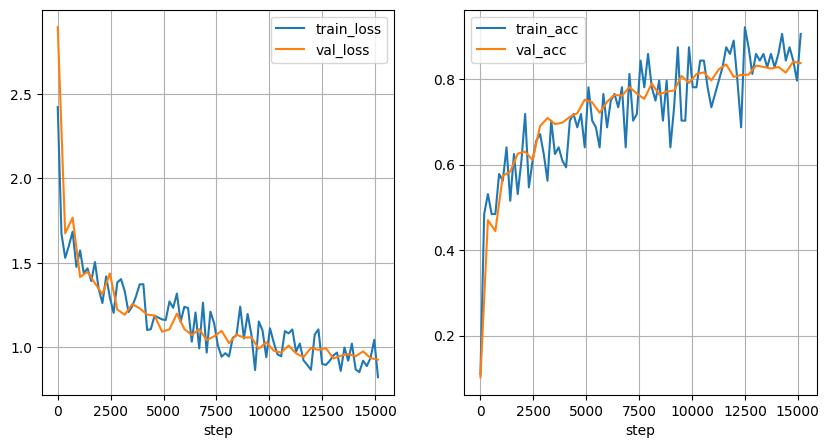

In [39]:
def plot_learning_curves(record_dict, sample_step=500):  # ── 注意：以下损失曲线的 y 轴不一定从 1 开始（取决于实际训练损失范围） ──────────
    """绘制训练集和验证集的损失与准确率随步数变化的曲线。

    参数:
        record_dict (dict): 训练函数返回的记录字典，包含 'train' 和 'val' 两个列表。
            每个列表中的元素为 {'loss': float, 'acc': float, 'step': int}。
        sample_step (int, optional): 训练曲线的采样间隔（步数），
            避免绘制过于密集的点，默认 500 步采样一个点。
    """
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]  # ── 构建训练集 DataFrame，以 step 为索引，并按 sample_step 间隔采样 ──────────
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")  # 构建验证集 DataFrame，以 step 为索引（验证集本身记录频率已较低，不再采样）

    fig_num = len(train_df.columns)   # 指标数量（loss 和 acc 共 2 个）
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))  # plt.subplots：创建 1 行 fig_num 列的子图布局，每个子图宽 5 英寸、高 5 英寸

    for idx, item in enumerate(train_df.columns):    # 遍历每个指标（loss、acc）
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")  # 绘制训练集曲线：x 轴为步数，y 轴为对应指标值
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")  # 绘制验证集曲线
        axs[idx].grid()           # 显示网格线，方便读取数值
        axs[idx].legend()         # 显示图例（train_xxx / val_xxx）
        axs[idx].set_xlabel("step")   # x 轴标签

    plt.show()   # 在 Jupyter Notebook 中显示图像
sample_step=eval_step//2
plot_learning_curves(record, sample_step)  # ── 调用绘图函数，每 100 步采样一个点以减少曲线过密 ─────────────────────────────


## 六、模型评估

### 6.1 加载最优检查点并在验证集上评估

In [41]:
# ── 加载最优模型检查点，在验证集上进行评估 ────────────────────────────────────────

# ── 加载检查点权重 ────────────────────────────────────────────────────────────
# torch.load(path, map_location='cpu')：将检查点加载到 CPU，
#   即使原来在 GPU 上保存的权重也可以在无 GPU 环境下加载
model.load_state_dict(torch.load(r"model_checkpoints/7_model/7_model_best.ckpt", map_location="cpu"))  # ── 加载检查点权重 ────────────────────────────────────────────────────────────；torch.load(path, map_location='cpu')：将检查点加载到 CPU，；即使原来在 GPU 上保存的权重也可以在无 GPU 环境下加载；model.load_state_dict(state_dict)：将权重字典加载到模型中，要求键名严格匹配


loss, acc = evaluating(model, eval_dl, loss_fct)  # ── 调用评估函数，计算验证集损失和准确率 ──────────────────────────────────────

print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")  # ── 打印评估结果（:.4f 保留 4 位小数） ──────────────────────────────────────────


loss:     0.9361
accuracy: 0.8414


## 七、测试集预测与结果提交

### 7.1 对测试集进行推理，收集预测标签

In [42]:
# ── 构建测试集 Dataset 和 DataLoader ──────────────────────────────────────────
test_ds = Cifar10Dataset("test", transform=transforms_eval)  # ── 构建测试集 Dataset 和 DataLoader ──────────────────────────────────────────；测试集使用 'test' 模式，应用评估变换（不做数据增强）
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)  # drop_last=False：保留最后一个不满 batch_size 的批次，确保所有测试样本都被预测

preds_collect = []   # 存储所有预测的类别名称字符串
model.eval()         # 切换为评估模式

for data, fake_label in tqdm(test_dl):   # fake_label 是占位符，测试集无真实标签
    data = data.to(device=device)        # 将图像批次移到指定设备

    logits = model(data)  # 前向推理：得到 logits (N, num_classes)

    # argmax(axis=-1)：取每个样本概率最大的类别索引，形状 (N,)
    # .cpu().tolist()：移到 CPU 并转为 Python list
    preds = [test_ds.idx_to_label[idx] for idx in logits.argmax(axis=-1).cpu().tolist()]  # argmax(axis=-1)：取每个样本概率最大的类别索引，形状 (N,)；.cpu().tolist()：移到 CPU 并转为 Python list；idx_to_label[idx]：将整数索引映射回类别名称字符串（如 3 -> 'cat'）
    preds_collect.extend(preds)   # 追加到总预测列表

# ── 将预测结果写入 test_df 的 'class' 列 ──────────────────────────────────────
test_df["class"] = preds_collect  # ── 将预测结果写入 test_df 的 'class' 列 ──────────────────────────────────────；test_df['class'] 原为占位符标签，现替换为模型预测结果

test_df.head()  # ── 打印前几行，验证预测结果格式是否正确 ──────────────────────────────────────


100%|██████████| 4688/4688 [02:38<00:00, 29.49it/s]


,filepath,class
0,data\cifar-10\test\1.png,deer
1,data\cifar-10\test\2.png,airplane
2,data\cifar-10\test\3.png,automobile
3,data\cifar-10\test\4.png,ship
4,data\cifar-10\test\5.png,airplane


### 7.2 将预测结果保存为 submission.csv

In [43]:
# ── 将预测结果保存为 Kaggle 提交格式的 CSV 文件 ───────────────────────────────
# to_csv(path, index=False)：  # 说明性注释
#   path：保存路径
#   index=False：不将 DataFrame 的行索引写入 CSV，保持格式简洁
test_df.to_csv("submission.csv", index=False)  # ── 将预测结果保存为 Kaggle 提交格式的 CSV 文件 ───────────────────────────────；path：保存路径；index=False：不将 DataFrame 的行索引写入 CSV，保持格式简洁；保存后可直接上传至 Kaggle 竞赛页面进行提交评分
